# Descriptive statistics exercises

This notebook contains all solutions of the exercises from [Section 1.3 Descriptive Statistics](https://minireference.com/static/excerpts/noBSstats/descriptive_statistics.pdf) in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={'figure.figsize': (4,2)},
)

%config InlineBackend.figure_format = 'retina'

In [3]:
# Set pandas precision
pd.set_option("display.precision", 2)

In [4]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory present and ready.


## Exercises 1: numerical variables

### E1.16
Compute the Mean, Min, Max, and Range of the effort variable in the students dataset.




In [7]:
students = pd.read_csv("datasets/students.csv")
efforts = students["effort"]

# mean
efforts.mean()

8.904666666666666

In [8]:
# min
efforts.min()

5.21

In [9]:
# max
efforts.max()

12.0

In [10]:
# range
efforts.max() - efforts.min()

6.79

### E1.17
Find Q1, Med, and Q3 of the `effort` variable in the students dataset.


In [11]:
efforts.quantile(q=0.25),

(7.76,)

In [12]:
efforts.median()

8.69

In [13]:
efforts.quantile(q=0.75)

10.350000000000001

### E1.18

Make a one-way frequency table for the `effort` variable,
using $[5,7),$ $[7,9),$ $[9,11),$ $[11,13)$ as the bin intervals.

In [14]:
bins = [5, 7, 9, 11, 13]
pd.cut(efforts, bins=bins, right=False).value_counts(sort=False)

effort
[5, 7)      2
[7, 9)      6
[9, 11)     5
[11, 13)    2
Name: count, dtype: int64

### E1.19

Consider the following Spear--Tukey box plot of the variable~$\mathbf{y}$.
        
![](https://raw.githubusercontent.com/minireference/noBSstats/main/exercises/src/attachments/data/descr-stats/descr_stats_from_boxplot.png)

Determine the values of the following descriptive statistics:
$\textbf{med}(\mathbf{y})$,
$\textbf{min}(\mathbf{y})$, $\textbf{max}(\mathbf{y})$,
$\textbf{Q}_{1}(\mathbf{y})$, $\textbf{Q}_{2}(\mathbf{y})$, $\textbf{Q}_{3}(\mathbf{y})$, 
$\textbf{IQR}(\mathbf{y})$, and $\textbf{range}(\mathbf{y})$.


### E1.20

We want to describe the dataset $\mathbf{x} = (1, 2, 3, 4, 5, 6, 50)$
by reporting a pair of numbers:
one measure of central tendency
and one measure of dispersion.   
a) Compute the mean $\textbf{mean}(\mathbf{x})$
and the standard deviation $\textbf{std}(\mathbf{x})$.  
b) Compute the median $\textbf{med}(\mathbf{x})$
and the interquartile range $\textbf{IQR}(\mathbf{x})$.    
c) Which pair of numbers provides a more faithful summary?

In [16]:
xs = pd.Series([1, 2, 3, 4, 5, 6, 50], name="x")

# a)
xs.mean(), xs.std()

(10.142857142857142, 17.65812911408012)

In [18]:
# b)
xs.median(), xs.quantile(q=0.75)-xs.quantile(q=0.25)

(4.0, 3.0)

**c)** The median and the interquartile range
are the better summary statistics in this case,
because they are not as affected by the outlier $x=50$.

## Exercises 2: two numerical variables

### E1.21

We're interested in the `age` variable and the `time` variable in the players dataset.

a) Draw a scatter plot of the `time` versus `age`  
b) Calculate the covariance $\mathbf{cov}(\texttt{age},\texttt{time})$  
c) Calculate the correlation coefficient $\mathbf{corr}(\texttt{age},\texttt{time})$  


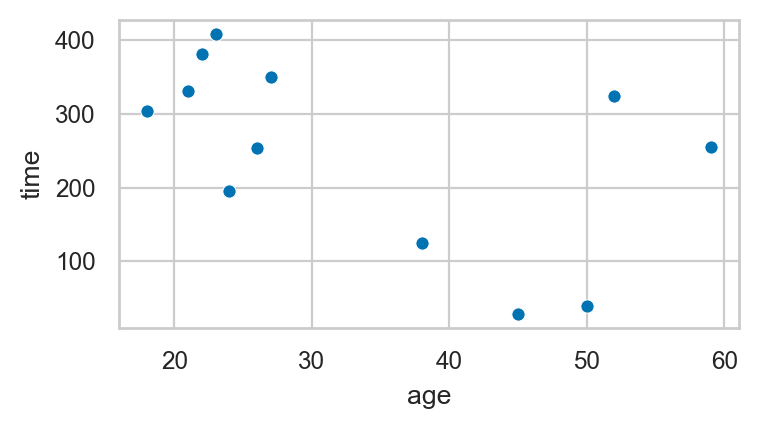

In [20]:
players = pd.read_csv("datasets/players.csv")

# a)
sns.scatterplot(data=players, x="age", y="time");

In [21]:
# b)
players[["age","time"]].cov()

,age,time
age,204.02,-931.53
time,-931.53,16348.66


The covariance is $\mathbf{cov}(\texttt{age},\texttt{time})=-931.53$,
which is the value we see in the top-right corner.
Note $\mathbf{cov}(\texttt{time},\texttt{age})$ in the bottom-left corner
has the same value.
This is because the covariance formula
$$
\mathbf{cov}(\mathbf{x},\mathbf{y})
  = \tfrac{1}{n-1}\!\sum^n_{i=1}(x_i- \overline{\mathbf{x}} )(y_i- \overline{\mathbf{y}}).
$$
is symmetric in the inputs $\mathbf{x}$ and $\mathbf{y}$.

In [22]:
# c)
players[["age","time"]].corr()

,age,time
age,1.00,-0.51
time,-0.51,1.00


The correlation coefficient is $\mathbf{corr}(\texttt{age},\texttt{time}) = -0.51$,
which means `age` is negatively associated with `time`.
The older the players are, the less time they spend in the game, on average.

## Exercises 3: comparing two groups of numerical variables

### E1.22

Compare electricity prices between the East and the West parts of the city.

a) generate a strip plot

b) compute the mean for each group

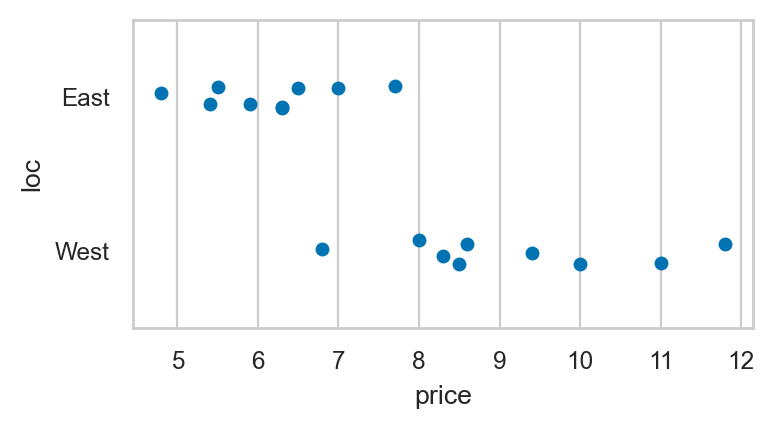

In [23]:
eprices = pd.read_csv("datasets/eprices.csv")

# a) scatter plot
sns.stripplot(data=eprices, x="price", y="loc");

In [24]:
# b) 
eprices[eprices["loc"]=="West"]["price"].mean()

9.155555555555557

In [25]:
eprices[eprices["loc"]=="East"]["price"].mean()

6.155555555555556

### E1.23

The doctors dataset has the categorical variable `loc` that represents the location
with two possible values `rur` and `urb`.
Compare the `score` variable between the `rur` and `urb` groups of doctors.

a) scatter plot  
b) box plots  
c) histograms  
d) descriptive statistics

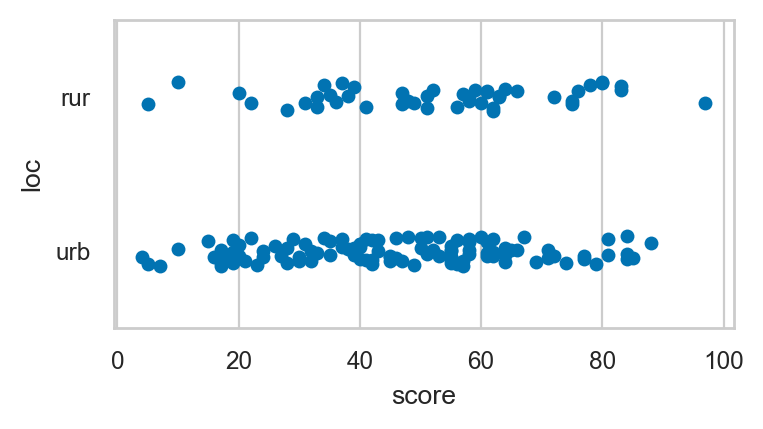

In [27]:
doctors = pd.read_csv("datasets/doctors.csv")

# a) scatter plot
sns.stripplot(data=doctors, x="score", y="loc");

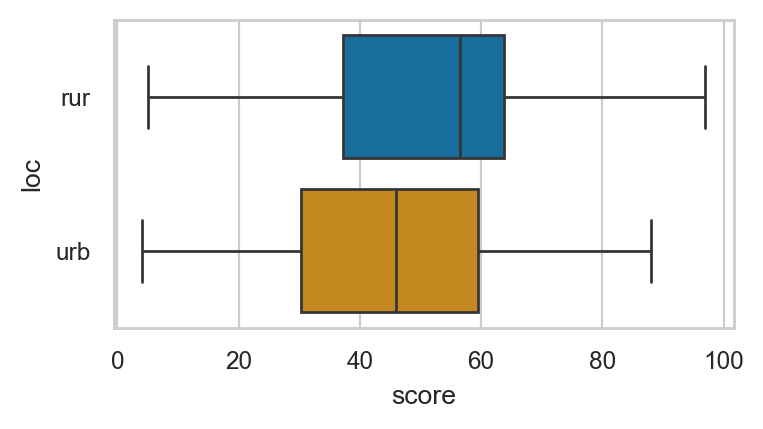

In [28]:
# b) box plots
sns.boxplot(data=doctors, x="score", y="loc", hue="loc");

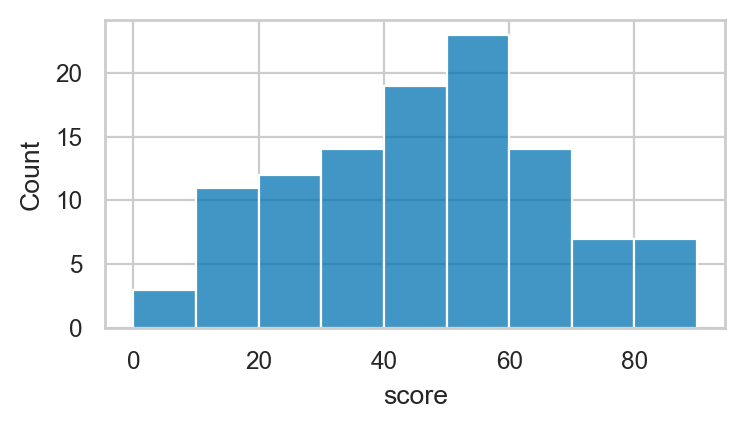

In [29]:
# c) histogram for urb doctors
bins = range(0,100,10)
urb_doctors = doctors[doctors["loc"]=="urb"]
sns.histplot(data=urb_doctors, x="score", bins=bins);

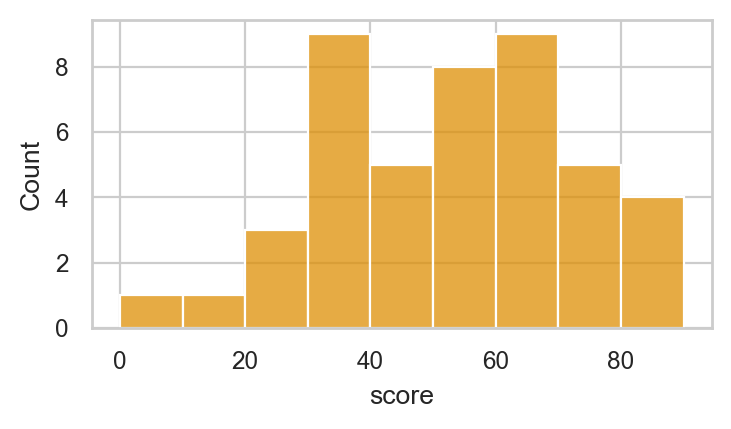

In [30]:
# c) histogram for rur doctors
rur_doctors = doctors[doctors["loc"]=="rur"]
sns.histplot(data=rur_doctors, x="score", bins=bins, color="C1");

In [31]:
# d) descriptive statistics
urb_doctors = doctors[doctors["loc"]=="urb"]
urb_doctors["score"].describe()

count    110.00
mean      45.96
std       20.22
min        4.00
25%       30.25
50%       46.00
75%       59.50
max       88.00
Name: score, dtype: float64

In [32]:
rur_doctors = doctors[doctors["loc"]=="rur"]
rur_doctors["score"].describe()

count    46.00
mean     52.96
std      20.36
min       5.00
25%      37.25
50%      56.50
75%      63.75
max      97.00
Name: score, dtype: float64

## Exercises 4: categorical variables

### E1.24
Compute frequencies and relative frequencies for the curriculum variable. Display the results in a one-way table.

In [33]:
students["curriculum"].value_counts()

curriculum
debate     8
lecture    7
Name: count, dtype: int64

In [34]:
students["curriculum"].value_counts(normalize=True)

curriculum
debate     0.53
lecture    0.47
Name: proportion, dtype: float64

### E1.25

Make a bar chart displaying the frequencies of the curriculum variable.


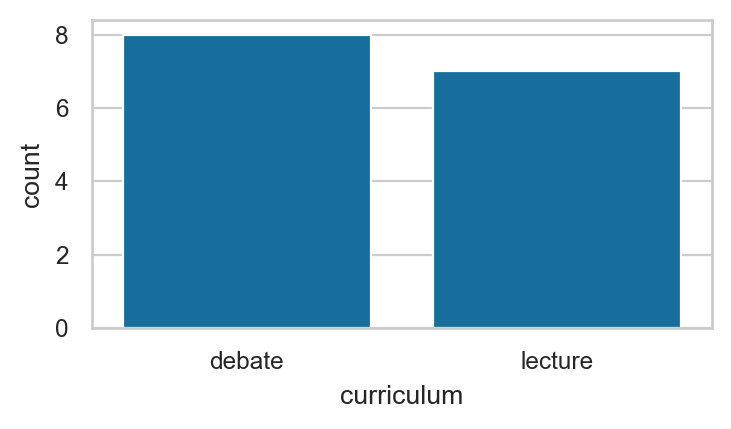

In [35]:
sns.countplot(data=students, x="curriculum");

### E1.26
What is the mode for variable `curriculum` in the students dataset?
How many times does the modal value occur in the `curriculum` data?

In [36]:
students["curriculum"].describe()

count         15
unique         2
top       debate
freq           8
Name: curriculum, dtype: object

In [37]:
students["curriculum"].count()

15

In [38]:
list(students["curriculum"].unique())

['debate', 'lecture']

In [39]:
mode = students["curriculum"].mode()
mode

0    debate
Name: curriculum, dtype: str

In [40]:
students["curriculum"].value_counts()[mode]

curriculum
debate    8
Name: count, dtype: int64

## Exercises 5: two categorical variables

### E1.27

Given the doctors dataset [`datasets/doctors.csv`](https://nobsstats.com/datasets/doctors.csv), generate:

a) a two-way table of the variables `work` and `loc`  
b) a grouped bar plot of the variables `work` and `loc`  
c) a stacked bar plot of the variables `work` and `loc`  

In [42]:
doctors = pd.read_csv("datasets/doctors.csv")

# a)
pd.crosstab(index=doctors["work"],
            columns=doctors["loc"],
            margins=True)

loc,rur,urb,All
work,,,
cli,32,56,88
eld,5,21,26
hos,9,33,42
All,46,110,156


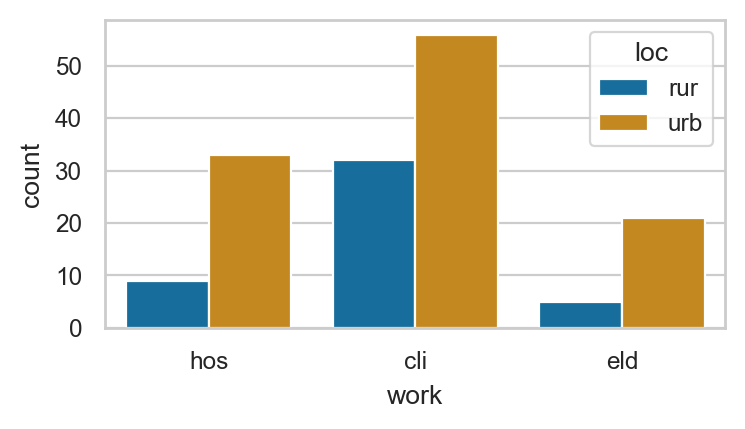

In [43]:
# b) grouped bar plot
sns.countplot(data=doctors, x="work", hue="loc");

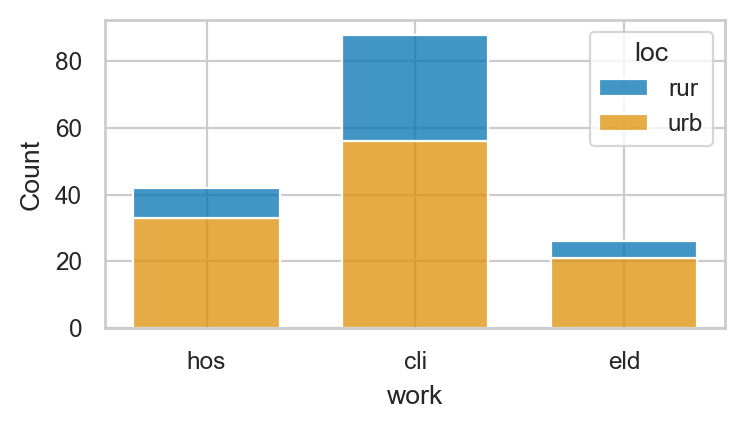

In [44]:
# c) stacked bar plot
sns.histplot(data=doctors, x="work", shrink=0.7,
             hue="loc", multiple="stack");

### E1.28

Load the visitors dataset (`datasets/visitors.csv`).   
a) compute a two-way table of the variables `version` and `bought`  
b) generate a grouped bar plot of the variables `version` and `bought`  
c) compute the conditional relative frequencies $\textbf{relfreq}_{\texttt{1}|\texttt{A}}(\texttt{version}, \texttt{bought})$ and $\textbf{relfreq}_{\texttt{1}|\texttt{B}}(\texttt{version}, \texttt{bought})$


In [46]:
visitors = pd.read_csv("datasets/visitors.csv")

# a)
pd.crosstab(index=visitors["version"],
            columns=visitors["bought"],
            margins=True)

bought,0,1,All
version,,,
A,880,61,941
B,1019,40,1059
All,1899,101,2000


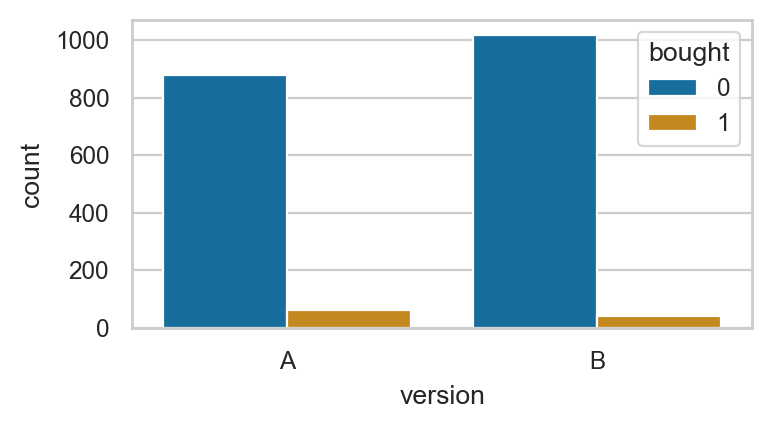

In [47]:
# b)
sns.countplot(data=visitors, x="version", hue="bought");

In [48]:
visitors = pd.read_csv("datasets/visitors.csv")

# c)
pd.crosstab(index=visitors["version"],
            columns=visitors["bought"],
            normalize="index", margins=True)

bought,0,1
version,,
A,0.94,0.06
B,0.96,0.04
All,0.95,0.05


## Exercises (end of section)

### E1.29

Calculate the mean and the standard devoatopm
of the variable `score` variable
in the doctors dataset.

In [49]:
doctors = pd.read_csv("datasets/doctors.csv")

doctors["score"].describe()

count    156.00
mean      48.03
std       20.45
min        4.00
25%       33.00
50%       49.50
75%       62.00
max       97.00
Name: score, dtype: float64

### E1.30

A research paper includes these graphs for the variable $\mathbf{x}$.	

![](https://raw.githubusercontent.com/minireference/noBSstats/main/exercises/src/attachments/data/descr-stats/descr_stats_from_plots.png)


The paper authors forgot to include the numerical summary statistics for the variable $\mathbf{x}$.
Use the information in the graphs to determine the values of the following descriptive statistics:
$\textbf{mean}(\mathbf{x})$, $\textbf{med}(\mathbf{x})$, $\textbf{std}(\mathbf{x})$, $\textbf{var}(\mathbf{x})$,
$\textbf{min}(\mathbf{x})$, $\textbf{Q}_{1}(\mathbf{x})$, $\textbf{Q}_{2}(\mathbf{x})$, $\textbf{Q}_{3}(\mathbf{x})$, $\textbf{max}(\mathbf{x})$,
$\textbf{IQR}(\mathbf{x})$, $\textbf{range}(\mathbf{x})$.
